In [1]:
%load_ext autoreload
%autoreload 2

## 1. Imports

In [2]:
import os
import sys

sys.path.append("..")

import numpy as np
import torch
from tqdm import tqdm

import wandb
from src.distributions import GridGaussiansSampler
from src.light_gcot import LightGCOT

In [3]:
device = torch.device(f"cuda:{torch.cuda.current_device()}" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

In [4]:
torch.set_default_device(device)
torch.torch.set_default_dtype(torch.float64)

## 2. Config

In [5]:
X_DIM = 2
Y_DIM = 2
assert X_DIM > 1
assert Y_DIM > 1

OUTPUT_SEED = 42

N_POTENTIALS = 100
M_POTENTIALS = 25
INIT_BY_SAMPLES = False
A_DIAGONAL_INIT = 0.3

BATCH_SIZE = 128
SAMPLING_BATCH_SIZE = 128

EPSILON = 0.002

D_LR = 1e-4  # 1e-3 for eps 0.1, 0.01 and 3e-4 for eps 0.002
D_GRADIENT_MAX_NORM = float("inf")

PLOT_EVERY = 1000
MAX_STEPS = 80000
CONTINUE = -1

In [6]:
torch.manual_seed(OUTPUT_SEED)
np.random.seed(OUTPUT_SEED)

In [7]:
EXP_COST = "MLP"
EXP_COST_INCLUDED = True
EXP_META_INFO = ""
EXP_NAME = (
    f"LightGCOT_Grid_Gaussians_EPSILON_{EPSILON}_MAX_STEPS_{MAX_STEPS}_N_{N_POTENTIALS}_M_{M_POTENTIALS}_with_{EXP_COST}_cost_included_{EXP_COST_INCLUDED}"
    + EXP_META_INFO
)
OUTPUT_PATH = "../checkpoints/{}".format(EXP_NAME)

config = dict(
    X_DIM=X_DIM,
    Y_DIM=Y_DIM,
    D_LR=D_LR,
    BATCH_SIZE=BATCH_SIZE,
    EPSILON=EPSILON,
    D_GRADIENT_MAX_NORM=D_GRADIENT_MAX_NORM,
    N_POTENTIALS=N_POTENTIALS,
    M_POTENTIALS=M_POTENTIALS,
    INIT_BY_SAMPLES=INIT_BY_SAMPLES,
    A_DIAGONAL_INIT=A_DIAGONAL_INIT,
)

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

## 3. Create samplers

In [8]:
X_sampler = GridGaussiansSampler(
    dim=X_DIM, 
    x_mode=4, 
    y_mode=4, 
    x_from=0.0,
    x_to=6.0,
    y_from=0.0,
    y_to=6.0,
    device=device,
)
Y_sampler = GridGaussiansSampler(
    dim=Y_DIM, 
    x_mode=4, 
    y_mode=4, 
    x_from=0.0,
    x_to=6.0,
    y_from=0.0,
    y_to=6.0,
    device=device,
)

## 4. Model initialization

In [9]:
D = LightGCOT(
    x_dim=X_DIM,
    y_dim=Y_DIM,
    n_potentials=N_POTENTIALS,
    m_potentials=M_POTENTIALS,
    epsilon=EPSILON,
    sampling_batch_size=SAMPLING_BATCH_SIZE,
    A_diagonal_init=A_DIAGONAL_INIT,
    cost_function=EXP_COST,
)

if INIT_BY_SAMPLES:
    D.init_a_by_samples(Y_sampler.sample(N_POTENTIALS))

D_opt = torch.optim.Adam(D.parameters(), lr=D_LR)

if CONTINUE > -1:
    D_opt.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_{OUTPUT_SEED}_{CONTINUE}.pt")))

## 5. Model training

In [10]:
from src.plotting import plot_A_parameters, plot_B_parameters, plot_gaussians

In [11]:
starting_points = X_sampler.mu[:3]

In [17]:
wandb.init(name=EXP_NAME, config=config)

for step in tqdm(range(CONTINUE + 1, 5 * MAX_STEPS)):
    # training loop
    D_opt.zero_grad()

    X, Y = X_sampler.sample(BATCH_SIZE), Y_sampler.sample(BATCH_SIZE)

    log_v_m = D.compute_log_v_m(X)  # [bs x M]
    b_m = D.compute_b_m(X)  # [bs x M x y_dim]

    log_w_n = D.compute_log_w_n()  # [N]
    a_n = D.compute_a_n()  # [N x y_dim]
    A_n = D.compute_A_n()  # [N x y_dim]

    f_c = D.compute_dual_potential(log_w_n, a_n, A_n, log_v_m, b_m)
    f = D.compute_primal_potential(Y, log_w_n, a_n, A_n)

    if EXP_COST_INCLUDED:
        c = D.compute_cost(Y, log_v_m, b_m)
        D_loss = (c - f_c - f).mean()
        D_loss.backward()
        wandb.log({r"$c(x, y)$": c.mean().item()}, step=step)
    else:
        D_loss = -(f_c + f).mean()
        D_loss.backward()
    D_gradient_norm = torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=D_GRADIENT_MAX_NORM)
    D_opt.step()

    wandb.log({f"D gradient norm": D_gradient_norm.item()}, step=step)
    wandb.log({f"D_loss": D_loss.item()}, step=step)
    wandb.log({r"$-f^c(x)$": -f_c.mean().item()}, step=step)
    wandb.log({r"$-f(y)$": -f.mean().item()}, step=step)
    wandb.log({r"$-f(y)-f^c(x)$": -(f_c + f).mean().item()}, step=step)
    wandb.log({f"lam_min(A_n)": torch.min(A_n)}, step=step)
    wandb.log({f"lam_max(A_n)": torch.max(A_n)}, step=step)

    if step % PLOT_EVERY == 0:
        A_dict = plot_A_parameters(D, log=True)
        B_dict = plot_B_parameters(D, starting_points, log=True)
        distr_dict = plot_gaussians(D, X_sampler, Y_sampler, log=True)
        wandb.log(A_dict | B_dict | distr_dict)

        torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D_{step}.pt"))
        torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_{step}.pt"))

torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D_{MAX_STEPS}.pt"))
torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_{MAX_STEPS}.pt"))

wandb.finish()

 17%|███████████████████████████                                                                                                                                | 69999/400000 [33:59<3:45:02, 24.44it/s]

: 

: 

: 

## Plotting

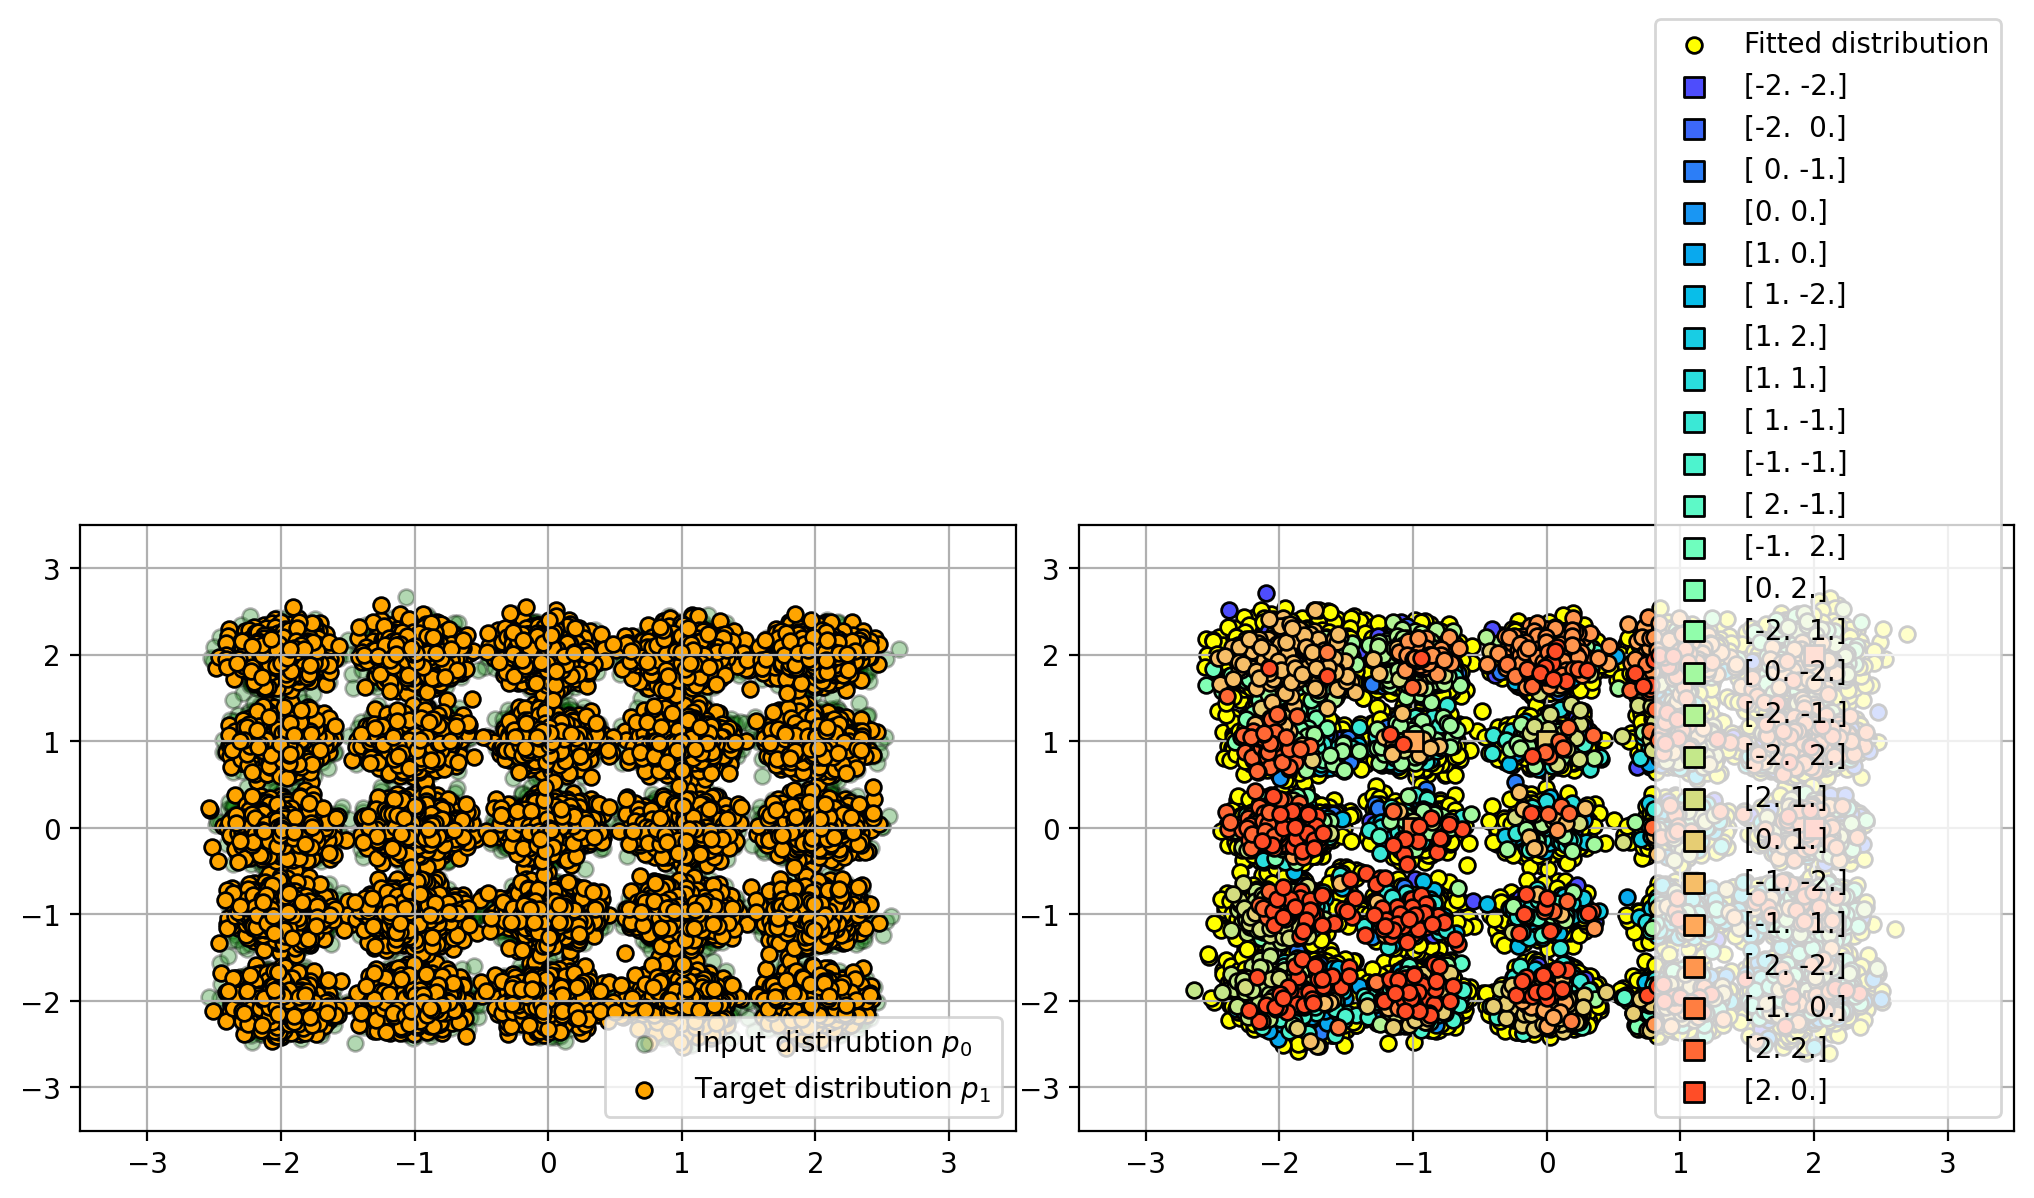

In [17]:
plot_distributions(D, X_sampler, Y_sampler, X_sampler.mu)